In [4]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn tensorflow joblib

In [5]:
import os
import re
import html
import json
import random
import time
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    GlobalAveragePooling1D,
    Conv1D,
    GlobalMaxPooling1D,
    SimpleRNN
)

from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


The main columns for our project are:

recipe_name: Name of the recipe.

stars: Rating given to the recipe.

text: Written review/comment.

thumbs_up and thumbs_down: Feedback on the comment.

We will use text as the NLP input and stars to create our sentiment labels.

In [8]:
from google.colab import files

uploaded = files.upload()

Saving Recipe Reviews and User Feedback Dataset.csv to Recipe Reviews and User Feedback Dataset (1).csv


In [9]:
# Find the uploaded CSV file
csv_files = [
    filename
    for filename in uploaded.keys()
    if filename.lower().endswith(".csv")
]

if not csv_files:
    raise FileNotFoundError("Please upload a CSV dataset.")

file_path = csv_files[0]

# Read the dataset
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (18182, 15)


,Unnamed: 0,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ..."
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...
2,2,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,3,0,5,710,I have a very complicated white chicken chili ...
3,3,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,2,0,0,581,"In your introduction, you mentioned cream chee..."
4,4,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,u_XXWKwVhKZD69,camper77,10,1664913823,1,7,0,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...


In [10]:
# Display column names
print("Columns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset information:")
df.info()

Columns:
['Unnamed: 0', 'recipe_number', 'recipe_code', 'recipe_name', 'comment_id', 'user_id', 'user_name', 'user_reputation', 'created_at', 'reply_count', 'thumbs_up', 'thumbs_down', 'stars', 'best_score', 'text']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18182 entries, 0 to 18181
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       18182 non-null  int64 
 1   recipe_number    18182 non-null  int64 
 2   recipe_code      18182 non-null  int64 
 3   recipe_name      18182 non-null  object
 4   comment_id       18182 non-null  object
 5   user_id          18182 non-null  object
 6   user_name        18182 non-null  object
 7   user_reputation  18182 non-null  int64 
 8   created_at       18182 non-null  int64 
 9   reply_count      18182 non-null  int64 
 10  thumbs_up        18182 non-null  int64 
 11  thumbs_down      18182 non-null  int64 
 12  stars            1

In [11]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0         0
recipe_number      0
recipe_code        0
recipe_name        0
comment_id         0
user_id            0
user_name          0
user_reputation    0
created_at         0
reply_count        0
thumbs_up          0
thumbs_down        0
stars              0
best_score         0
text               2
dtype: int64


In [12]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0         0
recipe_number      0
recipe_code        0
recipe_name        0
comment_id         0
user_id            0
user_name          0
user_reputation    0
created_at         0
reply_count        0
thumbs_up          0
thumbs_down        0
stars              0
best_score         0
text               2
dtype: int64


In [13]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
# Inspect rating distribution
print("Star distribution:")
print(df["stars"].value_counts(dropna=False).sort_index())

Star distribution:
stars
0     1696
1      280
2      232
3      490
4     1655
5    13829
Name: count, dtype: int64


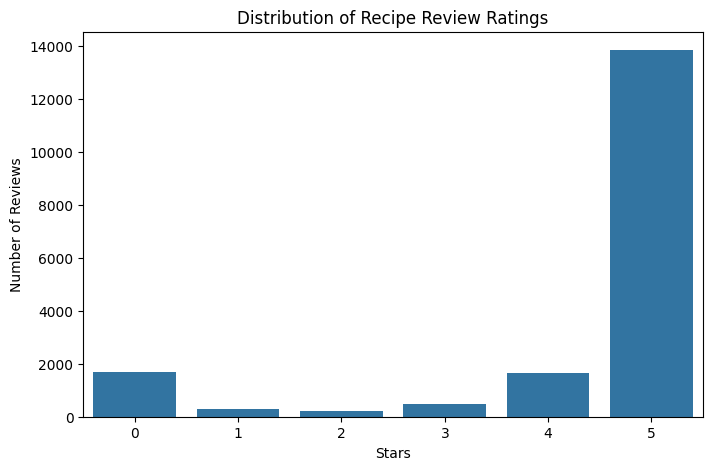

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="stars",
    order=sorted(df["stars"].dropna().unique())
)

plt.title("Distribution of Recipe Review Ratings")
plt.xlabel("Stars")
plt.ylabel("Number of Reviews")

plt.show()

We will retain only the columns needed for sentiment classification and analysis.

We will not use user_id or user_name as model features. This avoids making predictions based on user identity rather than review content.

In [17]:
# Check that required columns exist
required_columns = ["stars", "text"]

for column in required_columns:
    if column not in df.columns:
        raise ValueError(f"Required column missing: {column}")

# Keep useful columns that are available
selected_columns = [
    column for column in [
        "comment_id",
        "recipe_number",
        "recipe_name",
        "stars",
        "thumbs_up",
        "thumbs_down",
        "text"
    ]
    if column in df.columns
]

df = df[selected_columns].copy()

# Convert stars to numeric
df["stars"] = pd.to_numeric(
    df["stars"],
    errors="coerce"
)

# Remove missing ratings and review text
df = df.dropna(
    subset=["stars", "text"]
).copy()

# Convert text to string and remove whitespace
df["text"] = df["text"].astype(str).str.strip()

# Remove empty reviews
df = df[df["text"] != ""]

# Keep valid star ratings from 0 to 5
df = df[df["stars"].isin([0, 1, 2, 3, 4, 5])]

# Remove duplicate comments if comment_id is available
if "comment_id" in df.columns:
    df = df.drop_duplicates(
        subset=["comment_id"]
    )

df = df.reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)

display(df.head())

Cleaned dataset shape: (18177, 7)


,comment_id,recipe_number,recipe_name,stars,thumbs_up,thumbs_down,text
0,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,1,Creamy White Chili,5,0,0,"I tweaked it a little, removed onions because ..."
1,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,1,Creamy White Chili,5,7,0,Bush used to have a white chili bean and it ma...
2,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,1,Creamy White Chili,5,3,0,I have a very complicated white chicken chili ...
3,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,1,Creamy White Chili,0,2,0,"In your introduction, you mentioned cream chee..."
4,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,1,Creamy White Chili,0,7,0,Wonderful! I made this for a &#34;Chili/Stew&#...


In [18]:
# Keep only clearly positive and negative ratings
df = df[
    df["stars"].isin([1, 2, 4, 5])
].copy()

# Create sentiment labels
df["sentiment"] = df["stars"].apply(
    lambda rating: 0 if rating in [1, 2] else 1
)

df = df.reset_index(drop=True)

print("Dataset after sentiment filtering:", df.shape)

print("\nSentiment counts:")
print(df["sentiment"].value_counts())

print("\nSentiment percentages:")
print(
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Dataset after sentiment filtering: (15992, 8)

Sentiment counts:
sentiment
1    15480
0      512
Name: count, dtype: int64

Sentiment percentages:
sentiment
1    96.8
0     3.2
Name: proportion, dtype: float64


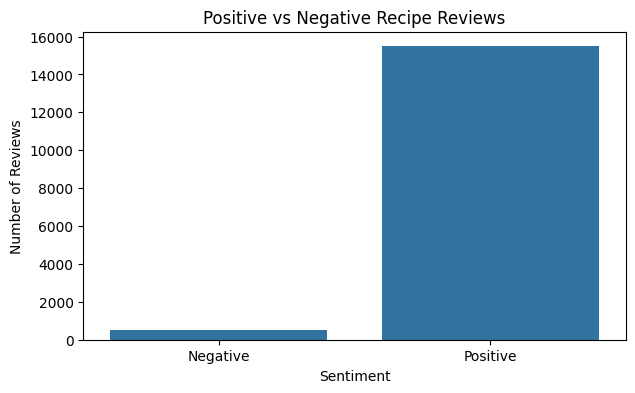

In [19]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.title("Positive vs Negative Recipe Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

# **NLP Text Processing**
Raw review text may contain:

HTML entities

HTML tags

URLs

Uppercase characters

Punctuation

Extra spaces

We will clean the text before converting it into numerical features.

We will preserve words such as not and never because they can change the meaning of a review.

In [21]:
def clean_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Keep alphabets and spaces
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    # Remove extra whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [22]:
# Apply text preprocessing
df["clean_text"] = df["text"].apply(clean_text)

# Remove empty cleaned reviews
df = df[
    df["clean_text"].str.len() > 0
].copy()

df = df.reset_index(drop=True)

display(
    df[["text", "clean_text", "stars", "sentiment"]].head(10)
)

,text,clean_text,stars,sentiment
0,"I tweaked it a little, removed onions because ...",i tweaked it a little removed onions because o...,5,1
1,Bush used to have a white chili bean and it ma...,bush used to have a white chili bean and it ma...,5,1
2,I have a very complicated white chicken chili ...,i have a very complicated white chicken chili ...,5,1
3,amazing! my boyfriend loved it so much! going ...,amazing my boyfriend loved it so much going to...,5,1
4,Wow!!! This recipe is excellent as written!! ...,wow this recipe is excellent as written the on...,5,1
5,I absolutely love this recipe. I&#39;ve tweake...,i absolutely love this recipe i ve tweaked it ...,5,1
6,I make this a lot … my kids and there friends ...,i make this a lot my kids and there friends co...,5,1
7,Best and easiest white chili recipe.,best and easiest white chili recipe,5,1
8,Best white chili recipe I&#39;ve had! I served...,best white chili recipe i ve had i served it u...,5,1
9,This recipe was excellent!! I added the cream ...,this recipe was excellent i added the cream ch...,5,1


In [23]:
# Compare original and cleaned reviews

for i in range(min(5, len(df))):

    print("Original review:")
    print(df["text"].iloc[i])

    print("\nCleaned review:")
    print(df["clean_text"].iloc[i])

    print("-" * 80)

Original review:
I tweaked it a little, removed onions because of onion haters in my house, used Italian seasoning instead of just oregano, and use a paprika/ cayenne mix and a little more than the recipe called for.. we like everything a bit more hot. The chili was amazing! It was easy to make and everyone absolutely loved it. It will now be a staple meal in our house.

Cleaned review:
i tweaked it a little removed onions because of onion haters in my house used italian seasoning instead of just oregano and use a paprika cayenne mix and a little more than the recipe called for we like everything a bit more hot the chili was amazing it was easy to make and everyone absolutely loved it it will now be a staple meal in our house
--------------------------------------------------------------------------------
Original review:
Bush used to have a white chili bean and it made this recipe super simple. I’ve written to them and asked them to please!, bring them back

Cleaned review:
bush used 

# **Train Test Split**
We will divide our dataset into:

Training: 80%

Validation: 10%

Testing: 10%

The training data will be used to train the models. Validation data will be used for model selection. Test data will be used for final evaluation.

We will use stratification to maintain the class distribution across the splits.

In [24]:
X = df["clean_text"].values
y = df["sentiment"].values

# First split: 80% training, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

# Second split: 10% validation, 10% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 12785
Validation samples: 1598
Testing samples: 1599


# **Handling class imbalance**
Our dataset has significantly more positive reviews than negative reviews.

If we train a model without addressing this imbalance, it may learn to predict positive sentiment for most reviews.

We will calculate class weights using only the training labels. These weights will be used in Logistic Regression and all three neural networks.

In [25]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(label): float(weight)
    for label, weight in zip(classes, weights)
}

print("Class weights:")
print(class_weights)

Class weights:
{0: 15.591463414634147, 1: 0.5165656565656566}


We will first implement a traditional machine-learning baseline.

TF-IDF converts words and word combinations into numerical features.

Logistic Regression learns a relationship between those features and sentiment labels.

This baseline gives us a point of comparison for our deep-learning models.

In [26]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Fit only on training text
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation and test data
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (12785, 10000)
Validation TF-IDF shape: (1598, 10000)
Testing TF-IDF shape: (1599, 10000)


In [47]:
tfidf_vectorizer = tfidf


In [27]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [29]:
# Validation predictions
lr_val_probs = lr_model.predict_proba(
    X_val_tfidf
)[:, 1]

lr_val_preds = (
    lr_val_probs >= 0.5
).astype(int)

print(
    classification_report(
        y_val,
        lr_val_preds,
        labels=[0, 1],
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.43      0.69      0.53        51
    Positive       0.99      0.97      0.98      1547

    accuracy                           0.96      1598
   macro avg       0.71      0.83      0.75      1598
weighted avg       0.97      0.96      0.96      1598



# **Prepare text for deep learning**
Neural networks need numerical input rather than raw sentences.

We will use:

Tokenizer: Converts words into integer IDs.

Padding: Makes all review sequences the same length.

Embedding: Learns a numerical vector representation for each word.

We will fit the tokenizer only on training reviews to avoid data leakage.

In [30]:
vocab_size = 10000
max_length = 200
embedding_dim = 128

# Initialize tokenizer
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

# Fit only on training reviews
tokenizer.fit_on_texts(X_train)

# Convert text into sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to a fixed length
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (12785, 200)
Validation shape: (1598, 200)
Testing shape: (1599, 200)


In [31]:
# See how a review is converted into numbers

sample_index = 0

print("Original review:")
print(X_train[sample_index])

print("\nInteger sequence:")
print(X_train_seq[sample_index][:30])

print("\nPadded sequence:")
print(X_train_pad[sample_index][:30])

Original review:
this was great full of flavor and simple to put together it wasn t time consuming either my kids absolutely loved this we added calorie guacomole also

Integer sequence:
[7, 14, 32, 317, 9, 87, 4, 227, 8, 115, 241, 5, 401, 22, 30, 896, 510, 13, 223, 140, 48, 7, 44, 35, 1602, 4254, 46]

Padded sequence:
[   7   14   32  317    9   87    4  227    8  115  241    5  401   22
   30  896  510   13  223  140   48    7   44   35 1602 4254   46    0
    0    0]


# **ANN**
An Artificial Neural Network (ANN) learns patterns from numerical representations of the review.

Our architecture:

Embedding layer converts word IDs into vectors.

Global average pooling combines word vectors.

Dense layers learn classification patterns.

Sigmoid output predicts the probability of positive sentiment.

In [32]:
ann_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    ),

    GlobalAveragePooling1D(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
ann_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

ann_history = ann_model.fit(
    X_train_pad,
    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,
    batch_size=32,

    class_weight=class_weights,

    callbacks=[ann_early_stopping],

    verbose=1
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.9011 - loss: 0.4834 - val_accuracy: 0.9349 - val_loss: 0.1842
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9416 - loss: 0.1748 - val_accuracy: 0.9543 - val_loss: 0.1369
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9729 - loss: 0.0999 - val_accuracy: 0.9606 - val_loss: 0.1233
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9833 - loss: 0.0536 - val_accuracy: 0.9599 - val_loss: 0.1380
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9878 - loss: 0.0355 - val_accuracy: 0.9643 - val_loss: 0.1578


# **CNN**

A Convolutional Neural Network (CNN) can be used for text classification.

A one-dimensional convolution scans across word embeddings and learns local patterns such as short phrases.

For example, it can learn useful patterns from phrases like:

"very tasty"

"not good"

"easy to make"

In [34]:
cnn_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    GlobalMaxPooling1D(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
cnn_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    X_train_pad,
    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,
    batch_size=32,

    class_weight=class_weights,

    callbacks=[cnn_early_stopping],

    verbose=1
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 54s 123ms/step - accuracy: 0.7800 - loss: 0.5144 - val_accuracy: 0.9431 - val_loss: 0.1681
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 77s 112ms/step - accuracy: 0.9399 - loss: 0.1851 - val_accuracy: 0.9599 - val_loss: 0.1336
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - accuracy: 0.9667 - loss: 0.1014 - val_accuracy: 0.9731 - val_loss: 0.1103
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 48s 119ms/step - accuracy: 0.9821 - loss: 0.0588 - val_accuracy: 0.9743 - val_loss: 0.1011
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 77s 106ms/step - accuracy: 0.9904 - loss: 0.0404 - val_accuracy: 0.9756 - val_loss: 0.0984
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - accuracy: 0.9971 - loss: 0.0091 - val_accuracy: 0.9750 - val_loss: 0.1307
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.9993 - loss: 0.0018 - val_accuracy: 0.9775 - val_loss: 0.1655


# **RNN**

Recurrent Neural Network (RNN) processes text sequentially.

It reads the sequence of words and maintains information from earlier words while processing later words.

This can help it learn word order and context.

For example:

"The recipe is good."

"The recipe is not good."

The word not changes the meaning. An RNN can learn patterns involving the order of words.

In [38]:
rnn_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    ),

    SimpleRNN(
        64,
        activation="tanh"
    ),

    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
rnn_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,
    batch_size=32,

    class_weight=class_weights,

    callbacks=[rnn_early_stopping],

    verbose=1
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.6932 - loss: 0.6175 - val_accuracy: 0.8730 - val_loss: 0.3408
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.9040 - loss: 0.2886 - val_accuracy: 0.9061 - val_loss: 0.2211
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.9488 - loss: 0.1470 - val_accuracy: 0.8742 - val_loss: 0.2925
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.9685 - loss: 0.0847 - val_accuracy: 0.9249 - val_loss: 0.2097
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.9713 - loss: 0.0598 - val_accuracy: 0.9650 - val_loss: 0.1412
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.9441 - loss: 0.1144 - val_accuracy: 0.9161 - val_loss: 0.2487
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.9743 - loss: 0.0550 - val_accuracy: 0.9499 - val_loss: 0.1700


# **Visualize Deep learning training**
We will visualize training and validation accuracy and loss for ANN, CNN, and RNN.

These plots help us identify whether the models are learning and whether they may be overfitting.

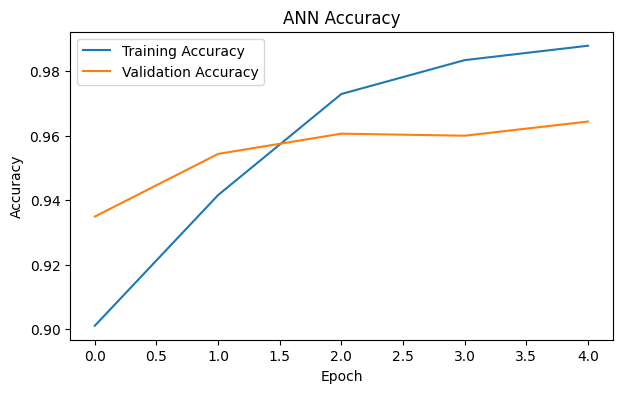

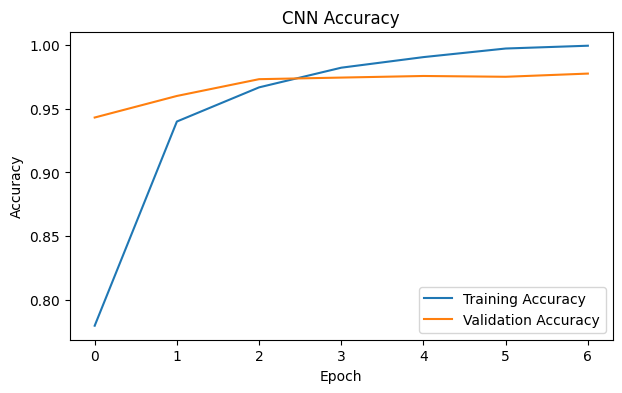

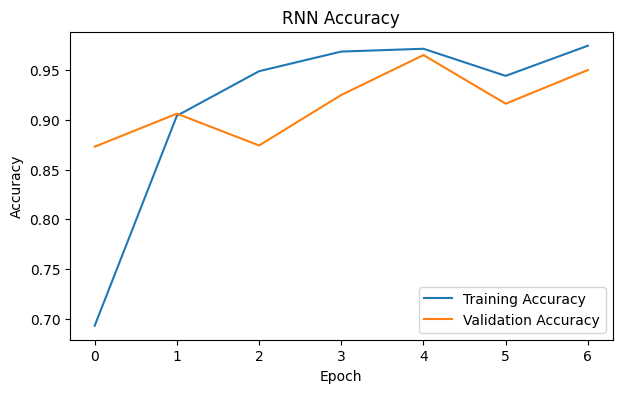

In [40]:
histories = {
    "ANN": ann_history,
    "CNN": cnn_history,
    "RNN": rnn_history
}

for model_name, history in histories.items():

    plt.figure(figsize=(7, 4))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

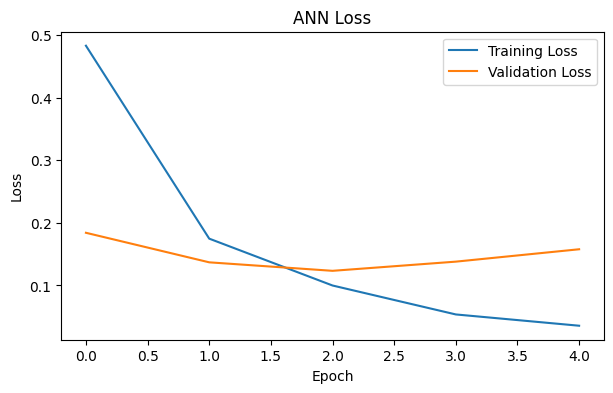

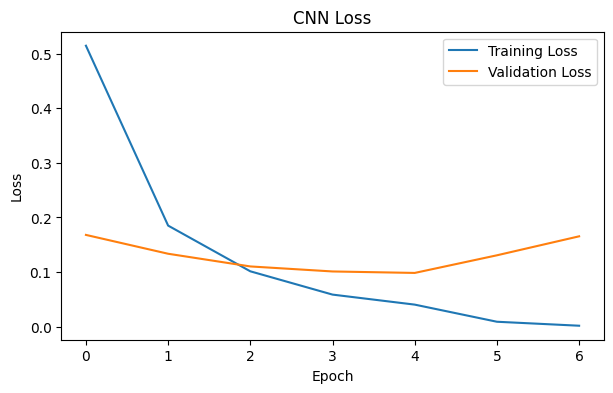

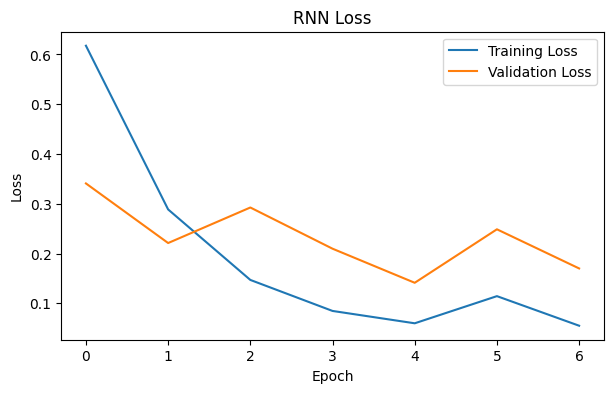

In [41]:
for model_name, history in histories.items():

    plt.figure(figsize=(7, 4))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

VALIDATION RESULTS


,Accuracy,Precision,Recall,F1 Score,Negative F1,Positive F1,Macro F1,ROC-AUC,Model
2,0.975594,0.985199,0.989657,0.987423,0.589474,0.987423,0.788449,0.926518,CNN
0,0.960576,0.989446,0.969619,0.979432,0.526316,0.979432,0.752874,0.949890,Logistic Regression
3,0.964956,0.984405,0.979315,0.981854,0.490909,0.981854,0.736381,0.914268,RNN
1,0.960576,0.983703,0.975436,0.979552,0.452174,0.979552,0.715863,0.931569,ANN


Best Model Selected: CNN

FINAL TEST RESULTS


,Accuracy,Precision,Recall,F1 Score,Negative F1,Positive F1,Macro F1,ROC-AUC,Model
2,0.977486,0.986486,0.990310,0.988395,0.625000,0.988395,0.806697,0.933697,CNN
0,0.966229,0.994048,0.970930,0.982353,0.608696,0.982353,0.795524,0.956820,Logistic Regression
3,0.967480,0.987614,0.978682,0.983128,0.551724,0.983128,0.767426,0.915096,RNN
1,0.967480,0.986346,0.979974,0.983150,0.535714,0.983150,0.759432,0.947383,ANN


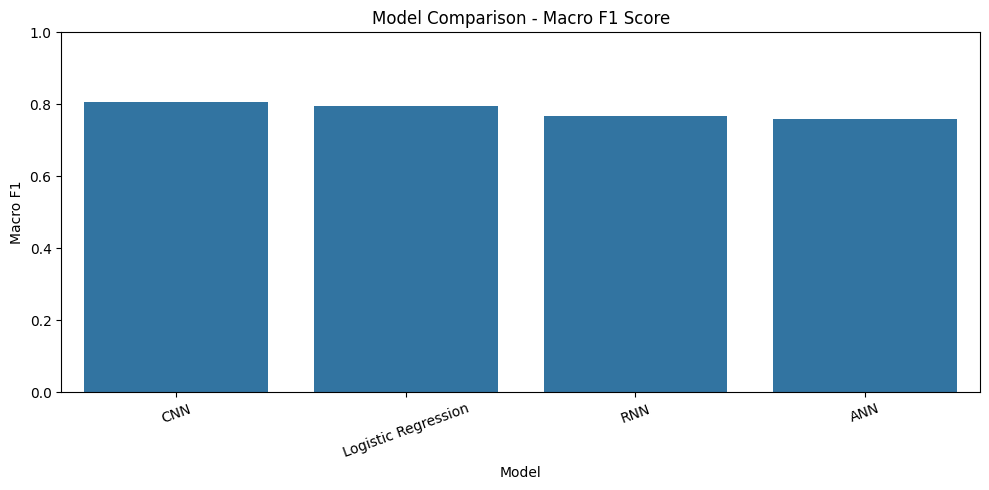


Classification Report: Logistic Regression
              precision    recall  f1-score   support

    Negative       0.48      0.82      0.61        51
    Positive       0.99      0.97      0.98      1548

    accuracy                           0.97      1599
   macro avg       0.74      0.90      0.80      1599
weighted avg       0.98      0.97      0.97      1599



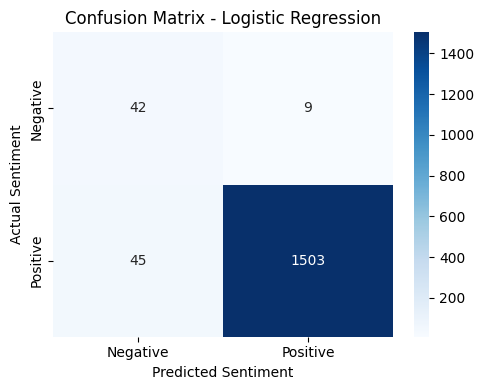


Classification Report: ANN
              precision    recall  f1-score   support

    Negative       0.49      0.59      0.54        51
    Positive       0.99      0.98      0.98      1548

    accuracy                           0.97      1599
   macro avg       0.74      0.78      0.76      1599
weighted avg       0.97      0.97      0.97      1599



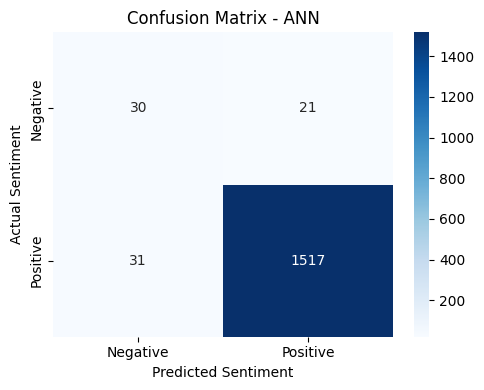


Classification Report: CNN
              precision    recall  f1-score   support

    Negative       0.67      0.59      0.62        51
    Positive       0.99      0.99      0.99      1548

    accuracy                           0.98      1599
   macro avg       0.83      0.79      0.81      1599
weighted avg       0.98      0.98      0.98      1599



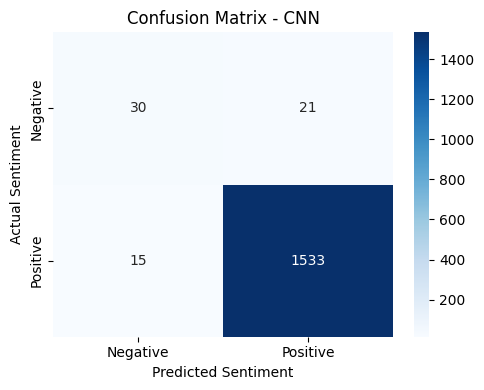


Classification Report: RNN
              precision    recall  f1-score   support

    Negative       0.49      0.63      0.55        51
    Positive       0.99      0.98      0.98      1548

    accuracy                           0.97      1599
   macro avg       0.74      0.80      0.77      1599
weighted avg       0.97      0.97      0.97      1599



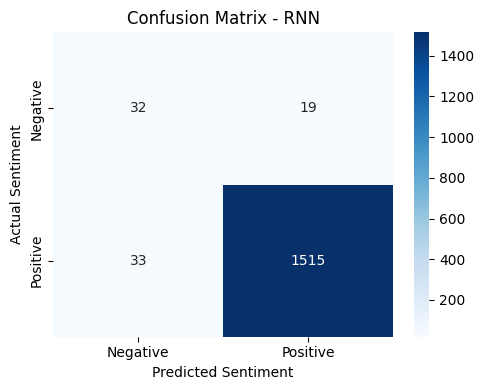

Best Model: CNN
Total Test Reviews: 1599
Misclassified Reviews: 36

Sample Misclassified Reviews:


,review,actual_sentiment,predicted_sentiment,positive_probability
14,i just made these following the recipe exactly...,Negative,Positive,0.741716
99,i had to bake for minutes longer than the dire...,Negative,Positive,0.999079
189,haven t made these due to the huge amount of c...,Negative,Positive,0.997161
235,the first time i had corn pudding i thought it...,Positive,Negative,0.144373
241,this should be stars but the website won t let...,Positive,Negative,0.068101
279,i just made my moms recipe for hot milk cake a...,Positive,Negative,0.004865
314,i felt it was somewhat bland i added celery se...,Positive,Negative,0.000240
325,why bother to see recipes if you can t print t...,Negative,Positive,0.515797
330,this fudge was dry,Negative,Positive,0.941723
343,i was so disappointed the long grain rice did ...,Negative,Positive,0.968111


Error analysis saved successfully!
INFERENCE TIME COMPARISON


,Model,Total Batch Time (seconds),Average Time Per Review (seconds)
0,Logistic Regression,0.000902,5.642145e-07
1,ANN,0.216880,1.356348e-04
2,CNN,1.147748,7.177911e-04
3,RNN,1.318055,8.242993e-04


Positive Review:


{'review': 'This recipe is delicious. My family loved it!',
 'predicted_sentiment': 'Positive',
 'positive_probability': 0.9999}


Negative Review:


{'review': 'The recipe was disappointing and tasted bland.',
 'predicted_sentiment': 'Negative',
 'positive_probability': 0.0}


========== PROJECT SUMMARY ==========
Training Records: 12785
Validation Records: 1598
Testing Records: 1599

Models Evaluated:
1. Logistic Regression
2. ANN
3. CNN
4. RNN

Best Model: CNN
Best Model Test Macro F1: 0.8067

Models and results saved successfully!
PROJECT COMPLETED!


In [48]:

# ============================================================
# PART:  COMPLETE MODEL EVALUATION AND FINAL ANALYSIS
# ============================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# EVALUATE MODELS ON VALIDATION DATA
# ------------------------------------------------------------

def calculate_metrics(y_true, probabilities):

    predictions = (probabilities >= 0.5).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_true, predictions, zero_division=0
        ),
        "Negative F1": f1_score(
            y_true, predictions, pos_label=0, zero_division=0
        ),
        "Positive F1": f1_score(
            y_true, predictions, pos_label=1, zero_division=0
        ),
        "Macro F1": f1_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }


ml_models = {
    "Logistic Regression": lr_model
}

deep_learning_models = {
    "ANN": ann_model,
    "CNN": cnn_model,
    "RNN": rnn_model
}

all_models = {
    **ml_models,
    **deep_learning_models
}

validation_results = []

for model_name, model in all_models.items():

    if model_name == "Logistic Regression":
        probabilities = model.predict_proba(X_val_tfidf)[:, 1]
    else:
        probabilities = model.predict(X_val_pad, verbose=0).ravel()

    metrics = calculate_metrics(y_val, probabilities)
    metrics["Model"] = model_name

    validation_results.append(metrics)


validation_df = pd.DataFrame(validation_results)

validation_df = validation_df.sort_values(
    by="Macro F1",
    ascending=False
)

print("VALIDATION RESULTS")
display(validation_df)


# ------------------------------------------------------------
# SELECT BEST MODEL AND EVALUATE ON TEST DATA
# ------------------------------------------------------------

best_model_name = validation_df.iloc[0]["Model"]

print("Best Model Selected:", best_model_name)

test_results = []
test_probabilities = {}

for model_name, model in all_models.items():

    if model_name == "Logistic Regression":
        probabilities = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        probabilities = model.predict(X_test_pad, verbose=0).ravel()

    test_probabilities[model_name] = probabilities

    metrics = calculate_metrics(y_test, probabilities)
    metrics["Model"] = model_name

    test_results.append(metrics)


comparison_df = pd.DataFrame(test_results)

comparison_df = comparison_df.sort_values(
    by="Macro F1",
    ascending=False
)

print("\nFINAL TEST RESULTS")
display(comparison_df)


# ------------------------------------------------------------
# VISUALIZE MODEL COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Macro F1"
)

plt.title("Model Comparison - Macro F1 Score")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# CLASSIFICATION REPORT AND CONFUSION MATRICES
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)

for model_name, probabilities in test_probabilities.items():

    predictions = (probabilities >= 0.5).astype(int)

    print("\nClassification Report:", model_name)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Negative", "Positive"],
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Sentiment")
    plt.ylabel("Actual Sentiment")
    plt.tight_layout()

    filename = model_name.lower().replace(" ", "_")

    plt.savefig(
        f"results/confusion_matrix_{filename}.png"
    )

    plt.show()



# ------------------------------------------------------------
# ERROR ANALYSIS USING THE BEST MODEL
# ------------------------------------------------------------

best_test_probabilities = test_probabilities[best_model_name]

best_test_predictions = (
    best_test_probabilities >= 0.5
).astype(int)

# Convert NumPy arrays or Pandas objects into Series
error_df = pd.DataFrame({
    "review": pd.Series(np.asarray(X_test).ravel()),
    "actual_sentiment": pd.Series(np.asarray(y_test).ravel()),
    "predicted_sentiment": best_test_predictions,
    "positive_probability": best_test_probabilities
})

# Identify incorrectly classified reviews
errors = error_df[
    errors_mask if False else
    error_df["actual_sentiment"] != error_df["predicted_sentiment"]
].copy()

# Convert numerical labels into readable sentiment labels
errors["actual_sentiment"] = errors[
    "actual_sentiment"
].map({
    0: "Negative",
    1: "Positive"
})

errors["predicted_sentiment"] = errors[
    "predicted_sentiment"
].map({
    0: "Negative",
    1: "Positive"
})

print("Best Model:", best_model_name)
print("Total Test Reviews:", len(error_df))
print("Misclassified Reviews:", len(errors))

print("\nSample Misclassified Reviews:")
display(errors.head(10))

# Save error analysis
errors.to_csv(
    "results/error_analysis.csv",
    index=False
)

print("Error analysis saved successfully!")


# ------------------------------------------------------------
# INFERENCE TIME COMPARISON
# ------------------------------------------------------------

inference_results = []

for model_name, model in all_models.items():

    start_time = time.perf_counter()

    if model_name == "Logistic Regression":
        model.predict_proba(X_test_tfidf)
    else:
        model.predict(X_test_pad, verbose=0)

    end_time = time.perf_counter()

    total_time = end_time - start_time

    inference_results.append({
        "Model": model_name,
        "Total Batch Time (seconds)": total_time,
        "Average Time Per Review (seconds)": (
            total_time / len(X_test)
        )
    })


inference_df = pd.DataFrame(inference_results)

print("INFERENCE TIME COMPARISON")
display(inference_df)


# ------------------------------------------------------------
# SAVE MODELS, RESULTS AND CREATE NEW REVIEW PREDICTION
# ------------------------------------------------------------

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Save traditional ML model and TF-IDF vectorizer
joblib.dump(
    lr_model,
    "models/logistic_regression.pkl"
)

joblib.dump(
    tfidf_vectorizer,
    "models/tfidf_vectorizer.pkl"
)

# Save deep learning models
ann_model.save("models/ann_model.keras")
cnn_model.save("models/cnn_model.keras")
rnn_model.save("models/rnn_model.keras")

# Save tokenizer
with open("models/tokenizer.json", "w") as file:
    file.write(tokenizer.to_json())

# Save evaluation results
validation_df.to_csv(
    "results/validation_comparison.csv",
    index=False
)

comparison_df.to_csv(
    "results/model_comparison.csv",
    index=False
)

inference_df.to_csv(
    "results/inference_time.csv",
    index=False
)

# Save selected best model
if best_model_name == "Logistic Regression":

    joblib.dump(
        logistic_regression,
        "models/best_logistic_regression.pkl"
    )

    joblib.dump(
        tfidf_vectorizer,
        "models/best_tfidf_vectorizer.pkl"
    )

else:

    deep_learning_models[best_model_name].save(
        "models/best_model.keras"
    )


# ------------------------------------------------------------
# NEW REVIEW SENTIMENT PREDICTION FUNCTION
# ------------------------------------------------------------

from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(review):

    cleaned_review = clean_text(review)

    if not cleaned_review.strip():
        return {
            "review": review,
            "predicted_sentiment": "Unable to predict",
            "positive_probability": None
        }

    if best_model_name == "Logistic Regression":

        review_tfidf = tfidf_vectorizer.transform(
            [cleaned_review]
        )

        probability = lr_model.predict_proba(
            review_tfidf
        )[0][1]

    else:

        review_sequence = tokenizer.texts_to_sequences(
            [cleaned_review]
        )

        review_padded = pad_sequences(
            review_sequence,
            maxlen=max_length,
            padding="post",
            truncating="post"
        )

        probability = deep_learning_models[
            best_model_name
        ].predict(
            review_padded,
            verbose=0
        )[0][0]

    sentiment = (
        "Positive" if probability >= 0.5
        else "Negative"
    )

    return {
        "review": review,
        "predicted_sentiment": sentiment,
        "positive_probability": round(float(probability), 4)
    }


# ------------------------------------------------------------
# TEST THE PREDICTION FUNCTION
# ------------------------------------------------------------

positive_review = (
    "This recipe is delicious. My family loved it!"
)

negative_review = (
    "The recipe was disappointing and tasted bland."
)

print("Positive Review:")
display(predict_sentiment(positive_review))

print("\nNegative Review:")
display(predict_sentiment(negative_review))


# ------------------------------------------------------------
# FINAL PROJECT SUMMARY
# ------------------------------------------------------------

print("\n========== PROJECT SUMMARY ==========")

print("Training Records:", len(X_train))
print("Validation Records:", len(X_val))
print("Testing Records:", len(X_test))

print("\nModels Evaluated:")
print("1. Logistic Regression")
print("2. ANN")
print("3. CNN")
print("4. RNN")

print("\nBest Model:", best_model_name)

best_test_macro_f1 = comparison_df.loc[
    comparison_df["Model"] == best_model_name,
    "Macro F1"
].iloc[0]

print("Best Model Test Macro F1:", round(best_test_macro_f1, 4))

print("\nModels and results saved successfully!")
print("PROJECT COMPLETED!")